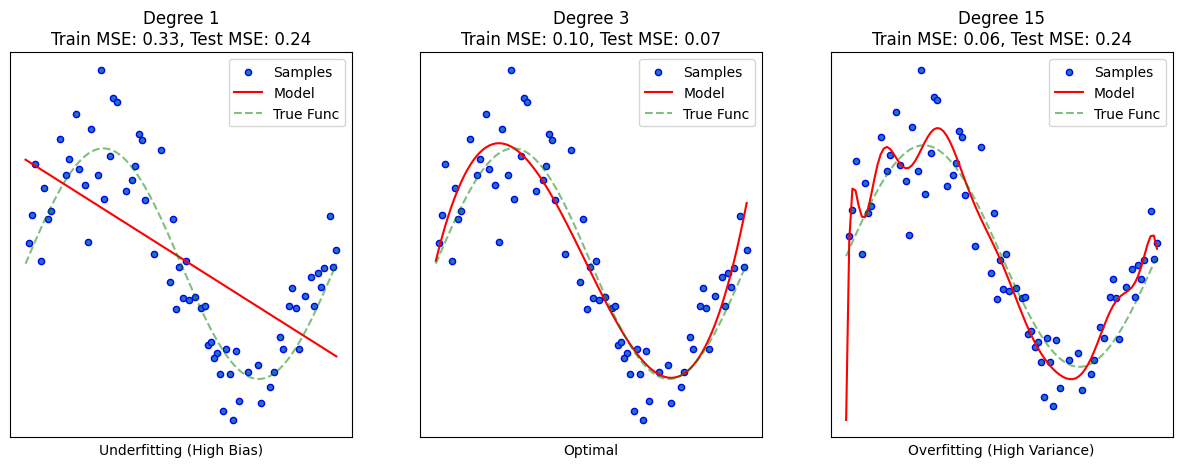

In [1]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def bias_variance_demo_polynomial_regression():
    """
    Illustrate underfitting/overfitting with polynomial regression.
    """
    # 1. Create Synthetic Data (Sine wave + Noise)
    rng = np.random.RandomState(0)
    X = np.linspace(0, 1, 100).reshape(-1, 1)
    y_true = np.sin(2 * np.pi * X).ravel()
    y = y_true + 0.3 * rng.randn(len(X)) # Add noise

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    degrees = [1, 3, 15]  # 1=High Bias, 3=Optimal, 15=High Variance

    plt.figure(figsize=(15, 5))

    for i, deg in enumerate(degrees):
        # Create pipeline
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=deg)),
            ("lr", LinearRegression())
        ])

        model.fit(X_train, y_train)

        # Calculate Errors
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        train_err = mean_squared_error(y_train, train_pred)
        test_err = mean_squared_error(y_test, test_pred)

        # Visualization
        ax = plt.subplot(1, 3, i + 1)
        plt.setp(ax, xticks=(), yticks=())

        # Plot Data
        plt.scatter(X_train, y_train, edgecolor='b', s=20, label="Samples")

        # Plot Model Curve
        X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
        plt.plot(X_plot, model.predict(X_plot), color='r', label="Model")
        plt.plot(X_plot, np.sin(2 * np.pi * X_plot), color='g', alpha=0.5, linestyle='--', label="True Func")

        plt.title(f"Degree {deg}\nTrain MSE: {train_err:.2f}, Test MSE: {test_err:.2f}")
        plt.legend(loc="best")

        if deg == 1: plt.xlabel("Underfitting (High Bias)")
        if deg == 3: plt.xlabel("Optimal")
        if deg == 15: plt.xlabel("Overfitting (High Variance)")

    plt.show()

bias_variance_demo_polynomial_regression()